In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory,plot_model
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
#Download the dataset from kaggle named as "Weather image Recognition" or link -> "https://www.kaggle.com/datasets/jehanbhathena/weather-dataset"

In [3]:

DATASET_PATH = "archive/dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20

In [4]:
train_ds=image_dataset_from_directory(
    DATASET_PATH,            #it is for loading the data from the directory
    validation_split=0.2,    #it is for splitting the data into training and validation sets, here 20% of the data will be used for validation  
    subset="training",       #it is for specifying that this dataset is for training
    seed=123,                #seed means that it is used to ensure that the data is split in the same way every time you run the code, it is for reproducibility 
    image_size=IMG_SIZE,     #it is for resizing the images to the specified size, here it will resize the images to 128x128 pixels
    batch_size=BATCH_SIZE    #it is for specifying the number of images to be included in each batch during training, here it will use a batch size of 32
)

val_ds=image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,                #seed means that it is used to ensure that the data is split in the same way every time you run the code, it is for reproducibility
    image_size=IMG_SIZE,     #it is for resizing the images to the specified size, here it will resize the images to 128x128 pixels
    batch_size=BATCH_SIZE    #it is for specifying the number of images to be included in each batch during training, here it will use a batch size of 32
)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.
Found 6862 files belonging to 11 classes.
Using 1372 files for validation.


In [5]:
#Further split validation ->Validation + test 
val_batches = tf.data.experimental.cardinality(val_ds) #it is for calculating the number of batches in the validation dataset, it returns the total number of batches in the validation dataset
test_ds = val_ds.take(val_batches // 2)                #it is for taking the first half of the validation dataset and using it as the test dataset, here it will take the first half of the validation dataset and use it as the test dataset
val_ds = val_ds.skip(val_batches // 2)                 #it is for skipping the first half of the validation dataset and using the remaining half as the validation dataset, here it will skip the first half of the validation dataset and use the remaining half as the validation dataset

In [6]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


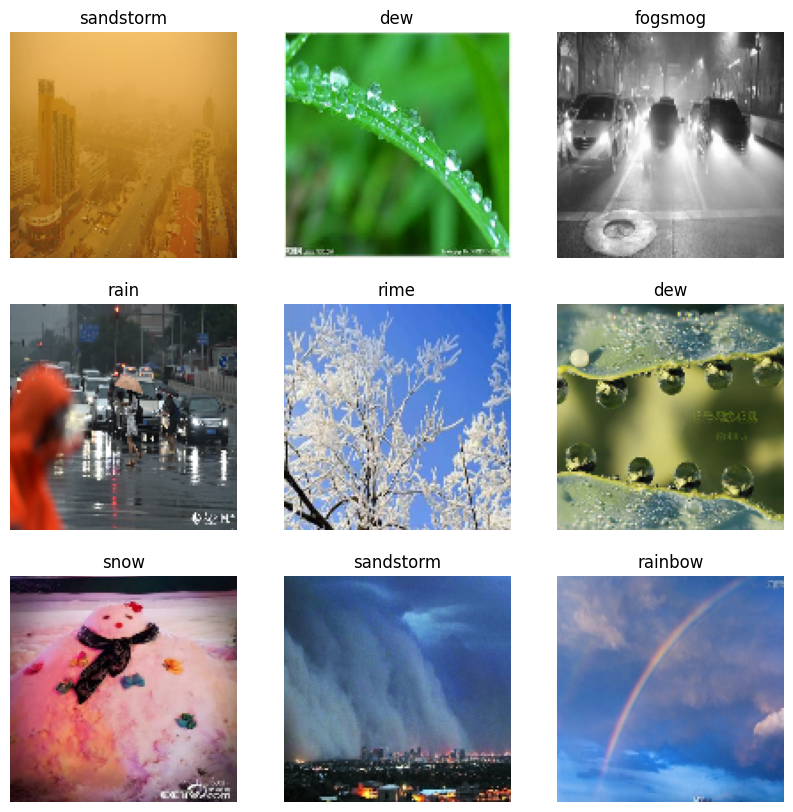

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #it is for taking one batch of images and labels from the training dataset, here it will take one batch of images and labels from the training dataset
    for i in range(9): #it is for iterating through the first 9 images and labels in the batch, here it will iterate through the first 9 images and labels in the batch
        ax = plt.subplot(3, 3, i + 1) #it is for creating a subplot with 3 rows and 3 columns, here it will create a subplot with 3 rows and 3 columns
        plt.imshow(images[i].numpy().astype("uint8")) #it is for displaying the image at index i in the batch, here it will display the image at index i in the batch
        plt.title(class_names[labels[i]]) #it is for setting the title of the subplot to the class name corresponding to the label at index i, here it will set the title of the subplot to the class name corresponding to the label at index i
        plt.axis("off") #it is for turning off the axis of the subplot, here it will turn off the axis of the subplot
    plt.show() #it is for displaying the plot, here it will display the plot

In [8]:
#Class Distribution
class_counts = {} #it is for creating an empty dictionary to store the count of each class, here it will create an empty dictionary to store the count of each class
for class_name in os.listdir(DATASET_PATH): 
    class_counts[class_name] = len(os.listdir(os.path.join(DATASET_PATH, class_name))) #it is for counting the number of images in each class and storing it in the dictionary, here it will count the number of images in each class and store it in the dictionary
print("Class distribution:", class_counts) #it is for printing the class distribution, here it will print the class distribution

Class distribution: {'dew': 698, 'fogsmog': 851, 'frost': 475, 'glaze': 639, 'hail': 591, 'lightning': 377, 'rain': 526, 'rainbow': 232, 'rime': 1160, 'sandstorm': 692, 'snow': 621}


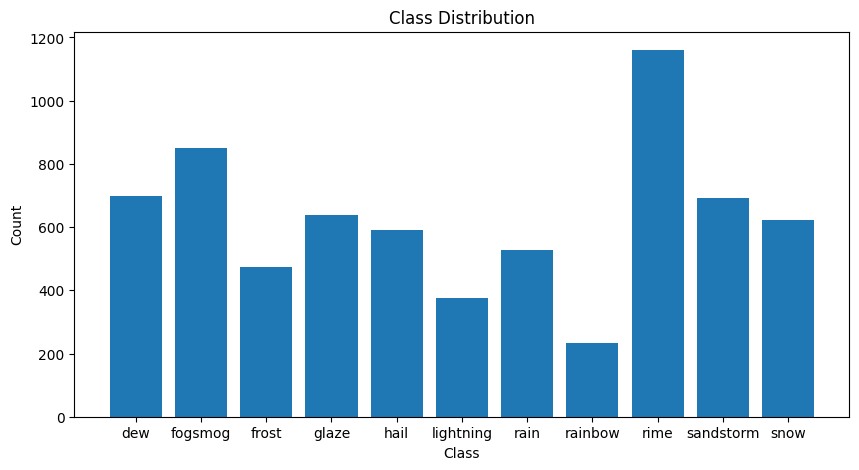

In [9]:
#bar plot for class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [10]:
# Normalization 
normalization_layer = layers.Rescaling(1./255) #it is for creating a normalization layer that rescales the pixel values to the range [0, 1], here it will rescale the pixel values to the range [0, 1]
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)) #it is for applying the normalization layer to the training dataset, here it will apply the normalization layer to the training dataset
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)) #it is for applying the normalization layer to the test dataset, here it will apply the normalization layer to the test dataset
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)) #it is for applying the normalization layer to the validation dataset, here it will apply the normalization layer to the validation dataset

In [11]:
#Performance Optimization

# AUTOTUNE mei tensorflow.data API ka ek feature hai jo automatic performance optimization enable karta hai, yeh data loading aur preprocessing ke dauran CPU aur GPU resources ka efficient use karta hai, yeh data pipeline ko optimize karta hai taaki training ke dauran bottlenecks na ho, yeh data loading, preprocessing, aur model training ke beech mein parallelism enable karta hai, jisse overall training time reduce hota hai.

AUTOTUNE = tf.data.AUTOTUNE #it is for enabling automatic performance optimization, here it will enable automatic performance optimization
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) #it is for caching the training dataset in memory, shuffling it with a buffer size of 1000, and prefetching it for improved performance during training, here it will cache the training dataset in memory, shuffle it with a buffer size of 1000, and prefetch it for improved performance during training
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE) #it is for caching the validation dataset in memory and prefetching it for improved performance during validation, here it will cache the validation dataset in memory and prefetch it for improved performance during validation
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE) #it is for caching the test dataset in memory and prefetching it for improved performance during testing, here it will cache the test dataset in memory and prefetch it for improved performance during testing

In [12]:
# model = models.Sequential([
#     layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(len(class_names), activation='softmax')
# ])
model = models.Sequential([
    layers.Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu',input_shape=(128,128,3)),
    layers.Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'),
    layers.Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu'),
    layers.Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=512,kernel_size=(3,3),padding='same',activation='relu'),
    layers.Conv2D(filters=512,kernel_size=(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers .Dense(units=1024,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(units=512,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(units=len(class_names),activation='softmax')
])



model.summary()

c:\Users\pmish\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    33,555,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,771,275 (147.90 MB)

 Trainable params: 38,771,275 (147.90 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
plot_model(model, to_file='model_arch.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 473s 3s/step - accuracy: 0.1960 - loss: 2.2634 - val_accuracy: 0.2686 - val_loss: 2.0130
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.3672 - loss: 1.8506 - val_accuracy: 0.4686 - val_loss: 1.6943
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.4880 - loss: 1.5378 - val_accuracy: 0.5271 - val_loss: 1.3971
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.5530 - loss: 1.3211 - val_accuracy: 0.5743 - val_loss: 1.2537
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.6056 - loss: 1.1927 - val_accuracy: 0.6157 - val_loss: 1.1544
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.6355 - loss: 1.0982 - val_accuracy: 0.6329 - val_loss: 1.0659
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.6525 - loss: 1.0415 - val_accuracy: 0.6657 - val_loss: 1.0366
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.6887 - loss: 0.9315 - val_accu

In [16]:
loss,accuracy = model.evaluate(test_ds)
print("Test Loss:", loss)

21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 518ms/step - accuracy: 0.6815 - loss: 1.5354
Test Loss: 1.5354360342025757


In [17]:
model.save("weather_classification_model.h5")

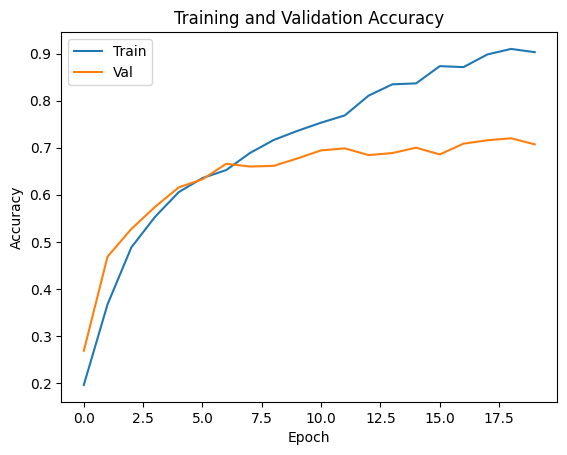

In [18]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Train', 'Val'],loc='upper left')
plt.show()